In [18]:
import numpy as np, matplotlib.pyplot as plt, scipy as sp
import matplotlib.image as mpimg
import torch
import time
import os, json
from datetime import datetime
import imageio.v3 as iio
from IPython.display import Image, display
from PIL import Image as PILImage


hbar = sp.constants.hbar
pi = sp.constants.pi

if torch.cuda.is_available():
    print(f"GPU is available: {torch.cuda.get_device_name(0)}")
else:
    print("GPU not found. Check your runtime settings.")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define simulation parameters

class CylindricalGPE:

    def __init__(self, Np, m, omega, a0, a02, gamma, sigma, N, ev_time,
                 time_steps, cutoff_coeff, cutoff, waist=False,
                 imag_waist=False, high_precision=False,
                 time_plots = False, final_plots = False, plot_steps = 0.1):

        self.debug = False
        self.time_plots = time_plots
        self.final_plots = final_plots
        self.plot_steps = plot_steps

        if not (self.plot_steps * time_steps).is_integer():
          print("Plot Step is not multiple of time steps. Choose plot step such that plot_step % of time_step = whole number.")

        if not int(1/self.plot_steps).is_integer():
          print("Choose plot step such that 1/plot_step is integer.")



        if high_precision:
            self.complex_type = torch.complex128
            self.real_type = torch.float64

        else:
            self.complex_type = torch.complex64
            self.real_type = torch.float32


        self.Np = Np
        self.m = m  #kg
        self.omega = omega #Hz
        self.a0 = a0 #m
        self.g0 = 4*pi*hbar**2*a0* Np/m
        self.gamma = gamma
        self.a02 = a02
        self.g2 = 6*np.sqrt(5) * pi * hbar**2 * a02 * Np / m
        self.sigma = sigma


        self.l = np.sqrt(hbar/(m * omega)) #length scale
        self.tau = 1/omega # time scale
        self.G0 = self.g0/(self.l**3*hbar*omega)
        self.G2 = self.g2/(hbar*omega*self.l**5)

        self.waist = waist
        self.imag_waist = imag_waist
        self.cutoff = cutoff

        self.up = 5 * sigma
        self.N = N
        self.ev_time = ev_time #s
        self.time_steps = time_steps
        self.dt = ev_time/time_steps
        self.dtau = self.dt/self.tau
        self.times = np.linspace(0, ev_time, time_steps)

        self.r = torch.linspace(0,self.up,self.N+1, device=device, dtype=self.real_type)[:-1]
        self.z = torch.linspace(-self.up, self.up,2*self.N+1, device=device, dtype=self.real_type)[:-1]
        self.dr = (self.r[1]-self.r[0]).item(); self.dru = self.dr/self.l
        self.dz = (self.z[1]-self.z[0]).item(); self.dzu = self.dz/self.l

        print(self.dr/self.dz)

        self.R, self.Z = torch.meshgrid(self.r,self.z, indexing='ij')
        self.uR,self.uZ = self.R/self.l, self.Z/self.l

        self.KZ = 2*pi*torch.fft.fftfreq(2*self.N, d=self.dz/self.l, device=device, dtype=self.real_type).unsqueeze(0)

        self.cutoff_coeff = cutoff_coeff
        self.k_cutoff = pi/self.dr * (self.cutoff_coeff) #m^-1

        if a02 == 0:
            self.elastic_term = False

        else: self.elastic_term = True


        self.init_wf = self.gaussian().to(device)
        self.n0 = torch.max(torch.abs(self.init_wf)**2).item() * self.Np
        self.healing_length = 1/np.sqrt(8*pi*self.n0*a0)


        self.parameters = {
            "Np": self.Np,
            "m": self.m,
            "omega": self.omega,
            "a0": self.a0,
            "g0": self.g0,
            "gamma": self.gamma,
            "a02": self.a02,
            "g2": self.g2,
            "sigma": self.sigma,
            "N": self.N,
            "ev_time": self.ev_time,
            "time_steps": self.time_steps,
            "dt": self.dt,
            "dtau": self.dtau,
            "dr": self.dr,
            "dru": self.dru,
            "up": self.up,
            "healing_length": self.healing_length,
            "cutoff_coeff": self.cutoff_coeff,
            "cutoff": self.cutoff,
            "high_precision": high_precision,
            "G0": self.G0,
            "G2": self.G2,
            "l": self.l,
            "tau": self.tau,
            "Peak Density": self.n0,
            "Gas Parameter": self.n0 * self.a0**3
        }

    def params(self):
        print("-- Simulation Parameters --")
        print("Number of particles:", self.Np)
        print("Mass (kg):", self.m)
        print("Trap frequency (Hz):", self.omega)
        print("Gamma: ", self.gamma)
        print("Scattering length a0 (m):", self.a0)
        print("Scattering length a02 (m^3):", self.a02)
        print("g2/g0:", self.g2/self.g0)
        print("Evolution time (s):", self.ev_time)
        print("Time steps: ", self.time_steps)
        print("dt: ", self.dt)
        print("dtau = dt/tau: ", self.dtau)
        print("Unitless Time (time/tau): ", self.ev_time/self.tau)
        print("Number of 1D grid points: ", self.N)
        print("dr:", self.dr)
        print("Healing length (m):", self.healing_length)
        print("dr/healing length:", self.dr/self.healing_length)
        print("up/healing length: ", self.up / self.healing_length)
        print("cutoff coeff:", self.cutoff_coeff)
        print("Cutoff Type: ", self.cutoff)
        print("K_Max: ", self.KZ.max().item())
        print("Particle Density: ", self.n0)
        print("na0^3: ", self.n0 * self.a0**3)

    def norm(self, f):
        mag = 2 * pi * torch.sum(torch.abs(f)**2 * self.dz * self.dr * self.R)
        return mag.item()

    def gaussian(self):
        sigma, dr = self.sigma, self.dr
        r, z = self.R, self.Z

        gaussian = torch.exp(-1*(r**2+z**2)/(2*sigma**2)).to(self.complex_type) # Gaussian ansatz exp(r^2/2sigma^2)
        norm = self.norm(gaussian)
        gaussian *= (1/norm)**(1/2)
        return gaussian

    def soft_cutoff(self):

        kc = self.k_cutoff * self.l
        delta_k = 0.1 * kc  # Unitless smearing width

        kx, ky, kz = self.KX, self.KY, self.KZ

        K_mag = torch.sqrt(kx**2+ky**2+kz**2)

        #exponent = torch.clip((K_mag - kc)/delta_k, -700, 700)

        #sig = 1/(1+torch.exp(exponent))

        sig = torch.sigmoid(-(K_mag - kc)/delta_k)

        return sig

    def save_plots(self):
        pass


    # Define operators

    def trap_potential(self):
        gam = self.gamma
        uR,uZ = self.uR, self.uZ
        return (1/2)*(uR**2+gam**2*uZ**2) # Non-dimensionalized potential; Note that factor of i–it's built into the function

    def g0_term(self, psi): # in position basis
        return self.G0 * torch.abs(psi)**2

    def finite_diff_op_row(self, ru, index, matrix):

        dt = self.dt
        dru = self.dru
        R = 1j * dt/(4*dru**2)
        points = len(ru)
        row = torch.zeros(points, dtype=self.complex_type, device=device)


        if index == 0:

            if matrix == "A":

                row[0] = 1 + 4 * R
                row[1] = -4 * R


            elif matrix == "B":

                row[0] = 1 - 4 * R
                row[1] = 4 * R

            return row


        elif index == points-1:

            Cm = 1 - dru/ru[-1]

            if matrix == "A":

                row[-1] = 1 + 2 * R
                row[-2] = -1 * Cm * R

            elif matrix == "B":

                row[-1] = 1 - 2 * R
                row[-2] = Cm * R

            return row


        elif 0 < index  < points-1 and isinstance(index, int):

            Cp = 1 + dru/ru[index]
            Cm = 1 - dru/ru[index]

            if matrix == "A":

                row[index] = 1 + 2 * R
                row[index+1] = -1 * Cp * R
                row[index-1] = -1 * Cm * R


            elif matrix == "B":

                row[index] = 1 - 2 * R
                row[index+1] = Cp * R
                row[index-1] = Cm * R


            return row


    def radial_kinetic_energy(self):

        r = self.r
        ru = r/self.l
        points = len(ru)

        Arows = tuple(self.finite_diff_op_row(ru, i, "A") for i in range(points))
        Brows = tuple(self.finite_diff_op_row(ru, i, "B") for i in range(points))

        A_matrix = torch.vstack(Arows)
        B_matrix = torch.vstack(Brows)

        # To use A_marix for finite difference method, we must use scipy.linalg.solve_banded
        # This requires to put the matrix into a specific form called ab, detailed in the documentation: ab[u+i-j,j]

        ab = torch.zeros((1+1+1, points))

        for i, row in enumerate(A_matrix):
            for j, elem in enumerate(row):

                if abs(i-j) <= 1: # Only fill in the diagonals and first off-diagonals

                    ab[1+i-j, j] = A_matrix[i,j]

        return A_matrix, B_matrix # We do not send the banded form because we are using linalg.solve in PyTorch directly


    def axial_kinetic_energy(self):
        kz = self.KZ
        return (1/2) * kz**2 # Note this FT of -d^2/dz^2

    def quadrupole_term(self, psi):

        kx, ky, kz = self.KX, self.KY, self.KZ

        psi_mag_fft = torch.fft.fftn(torch.abs(psi)**2)
        op = psi_mag_fft * ((1/3)*(kx**2+ky**2+kz**2) - kz**2)

        if self.cutoff == "Hard Cutoff":

            k2 = kx**2+ky**2+kz**2
            unitless_k = (self.k_cutoff * self.l)**2

            mask = (k2 < (self.k_cutoff*self.l)**2)

            op *=mask

            op = self.G2 * torch.real(torch.fft.ifftn(op))

            return op

        elif self.cutoff == "Cylinder Cutoff":

            k2 = kx**2+ky**2+kz**2
            unitless_k = (self.k_cutoff * self.l)**2

            rho2 = kx**2+ky**2
            mask = (rho2 < unitless_k) & (kz**2 < unitless_k)

            op *=mask

            op = self.G2 * torch.real(torch.fft.ifftn(op))

            return op

        elif self.cutoff == "Soft Cutoff":

            sig = self.soft_cutoff()

            op *= sig

            op = self.G2 * torch.real(torch.fft.ifftn(op))

            return op


        elif self.cutoff == "No Cutoff":

            return self.G2 * torch.real(torch.fft.ifftn(op))

        else:
            raise ValueError("Invalid cutoff type. Choose from 'Hard Cutoff', 'Cylinder Cutoff', 'Soft Cutoff', or 'No Cutoff'.")


    def plot_xy_density(self, wf):
        from scipy.interpolate import interp1d

        # 1. Get the 2D probability density and integrate out the Z-axis
        density_rz = np.abs(wf.cpu().numpy())**2
        dz = self.dz

        # Summing along axis 1 (the Z-axis) gives us a 1D array of length N_r
        radial_column_density = np.sum(density_rz * dz, axis=1)
        r_array = self.r.cpu().numpy()

        # 2. Build a new 2D Cartesian grid (X, Y)
        r_max = r_array.max()

        # We use 2*N points to match the resolution of your Z-axis and keep it smooth
        x = np.linspace(-r_max, r_max, 2 * self.N)
        y = np.linspace(-r_max, r_max, 2 * self.N)
        X, Y = np.meshgrid(x, y, indexing='ij')

        # Calculate the radial distance for every single pixel on this new grid
        R_grid = np.sqrt(X**2 + Y**2)

        # 3. Interpolate the 1D radial density onto the 2D Cartesian grid
        # bounds_error=False and fill_value=0.0 ensure that the corners of the square
        # grid (which fall outside the cylinder's radius) are simply set to 0 density.
        interpolator = interp1d(r_array, radial_column_density, kind='cubic',
                                bounds_error=False, fill_value=0.0)

        xy_density = interpolator(R_grid)

        # 4. Plot the result
        fig, ax = plt.subplots(figsize=(7, 6))

        # Divide by self.l to plot in unitless distance coordinates
        im = ax.pcolormesh(X/self.l, Y/self.l, xy_density, shading='auto')

        ax.set_title("XY Column Density")
        ax.set_xlabel("X (unitless)")
        ax.set_ylabel("Y (unitless)")
        fig.colorbar(im, ax=ax, label="Column Density")

        # CRITICAL: This forces the X and Y axes to scale equally so your
        # cloud actually looks like a perfect circle instead of a squished oval!
        ax.set_aspect('equal')

        plt.tight_layout()
        plt.show()


    @torch.compile
    def single_loop(self, wf, potential_step, KE_step, A_matrix, B_matrix):

        dtau = self.dtau

        wf *= potential_step

        # Apply momentum-basis operators for interval dt

        wf = torch.fft.fft(wf,dim=1)

        wf *= KE_step

        wf = torch.fft.ifft(wf, dim=1)

        # Apply position-basis operators for interval dt/2

        B_wf = B_matrix @ wf

        wf = torch.linalg.solve(A_matrix, B_wf) # Will overwrite help since we don't need it?

        wf *= potential_step

        wf *= torch.exp(-1j*(self.g0_term(wf)) * (dtau/2))

        return wf


    def evolution(self, ground_state=False):

        time_steps = self.time_steps

        dru = self.dr/self.l
        dtau = self.dtau # unitless time step
        dt = self.dt


        self.params()

        uR, uZ = self.uR, self.uZ
        dr = self.dr
        l = self.l

        wf = self.init_wf

        print("Psi initial normalization:", self.norm(wf))

        #Nondimensionalization
        wf = (wf * l**(3/2)).to(self.complex_type)

        potential_step = torch.exp(-1j *(self.trap_potential()) * (dtau/2))
        KE_step = torch.exp(-1j*(self.axial_kinetic_energy()) * dtau)
        A_matrix, B_matrix = self.radial_kinetic_energy()

        waist = []

        og_start_time = time.perf_counter()
        start_time = time.perf_counter()

        print("Starting: 0% done")

        self.energy = 0
        self.energies = []

        for i in range(time_steps):

            wf = self.single_loop(wf, potential_step, KE_step, A_matrix, B_matrix)

            self.energies.append(self.energy)

            if (i % (time_steps* self.plot_steps) == 0 and i > 0) or (i == time_steps-1):
                    print("Roughly {}% done".format(i/time_steps*100))
                    print("Elapsed time: {:.2f} minutes".format((time.perf_counter()-start_time)/60))
                    start_time = time.perf_counter()

                    self.t = str(np.round(i * dt*1000, decimals=1)).replace(".", "_")
                    self.index = str(i)
                    if self.time_plots: self.save_plots(wf)

            #if self.waist: waist.append(np.sum(np.abs(wf)**2 * uR**2)*dru**3)

        print("Total time: ", time.perf_counter()-og_start_time)

        waist = np.array(waist) * self.l**2
        self.waist_array = waist

        # Redimensionalize result

        redim_wf = wf* self.l**(-3/2)

        self.redim_wf = redim_wf.cpu().numpy()
        wf = wf.cpu().numpy()

        print("Final WF normalization", self.norm(redim_wf))

        return wf


    def dprint(self, *args):
        if self.debug:
            print(*args)

GPU not found. Check your runtime settings.


1.0000056585357384
-- Simulation Parameters --
Number of particles: 100000.0
Mass (kg): 1.9e-25
Trap frequency (Hz): 251.32741228718345
Gamma:  1
Scattering length a0 (m): 2e-09
Scattering length a02 (m^3): 6.666666666666667e-28
g2/g0: 1.1180339887498947e-18
Evolution time (s): 0.01
Time steps:  10000
dt:  1e-06
dtau = dt/tau:  0.0002513274122871834
Unitless Time (time/tau):  2.5132741228718345
Number of 1D grid points:  300
dr: 1.83333341396974e-07
Healing length (m): 1.2142420148220058e-06
dr/healing length: 0.1509858324444889
up/healing length:  45.2957477410814
cutoff coeff: 0.3333333333333333
Cutoff Type:  Soft Cutoff
K_Max:  25.380617141723633
Particle Density:  1.34933452423168e+19
na0^3:  1.0794676193853442e-07
Psi initial normalization: 1.0000001192092896
Starting: 0% done
Roughly 10.0% done
Elapsed time: 0.56 minutes
Roughly 20.0% done
Elapsed time: 0.51 minutes
Roughly 30.0% done
Elapsed time: 0.54 minutes
Roughly 40.0% done
Elapsed time: 0.51 minutes
Roughly 50.0% done
Elap

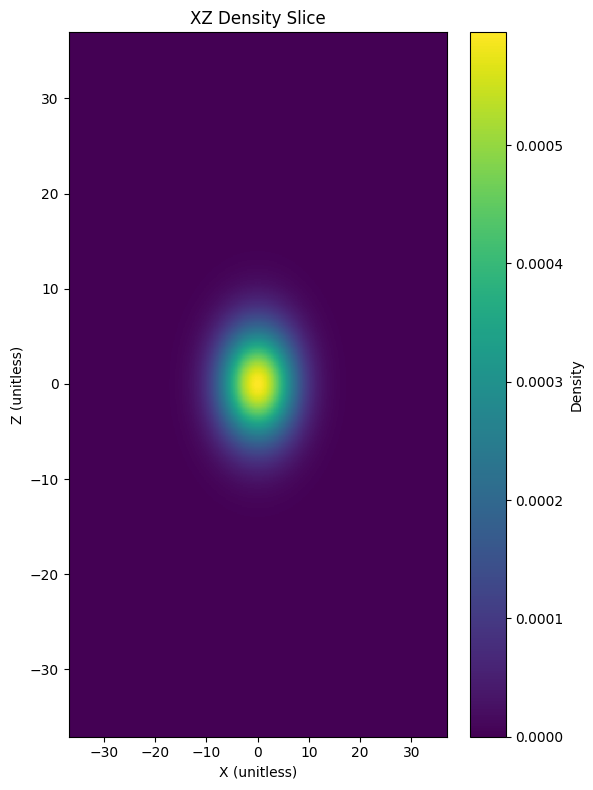

In [19]:
sim = CylindricalGPE(Np=1e5, m = 1.9e-25,
omega = 2 * pi * 40,
a0 = 2e-9,
gamma = 1,
a02 = (2/3)*1e-27,
sigma = 11e-6,
N=300,
ev_time = 0.01, #s
time_steps = 10000,
cutoff_coeff = 1/3,
cutoff="Soft Cutoff")

final_wf = sim.evolution()
density = np.abs(final_wf)**2
r = sim.r.cpu().numpy()
z = sim.z.cpu().numpy()

# 1. Mirror the r-axis to create a full x-axis (from -r_max to +r_max)
# We use r[1:] on the right side so we don't duplicate the r=0 origin point
x_axis = np.concatenate([-r[::-1], r[1:]])

# 2. Mirror the density array to match
xz_density = np.vstack((density[::-1, :], density[1:, :]))

# 3. Create the meshgrid for plotting
pX, pZ = np.meshgrid(x_axis, z, indexing='ij')

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.pcolormesh(pX/sim.l, pZ/sim.l, xz_density)
ax.set_title("XZ Density Slice")
ax.set_xlabel("X (unitless)")
ax.set_ylabel("Z (unitless)")
fig.colorbar(im, ax=ax, label="Density")

plt.tight_layout()
plt.show()

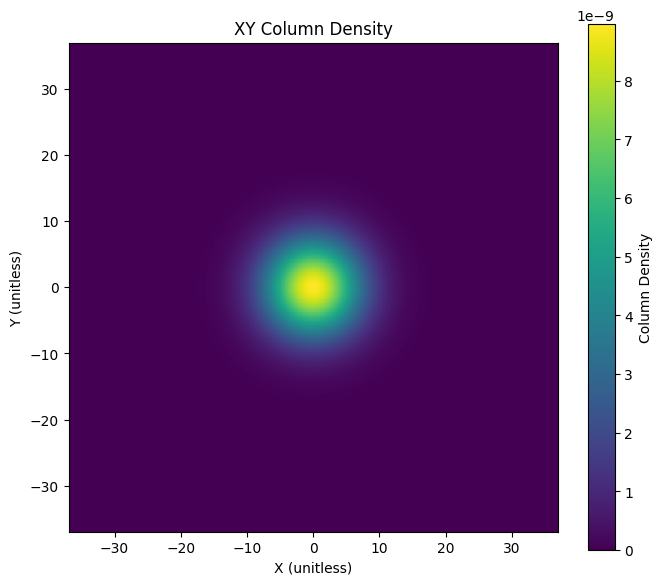

In [21]:
from scipy.interpolate import interp1d

# 1. Get the 2D probability density and integrate out the Z-axis
density_rz = np.abs(final_wf)**2
dz = sim.dz

# Summing along axis 1 (the Z-axis) gives us a 1D array of length N_r
radial_column_density = np.sum(density_rz * dz, axis=1)
r_array = sim.r.cpu().numpy()

# 2. Build a new 2D Cartesian grid (X, Y)
r_max = r_array.max()

# We use 2*N points to match the resolution of your Z-axis and keep it smooth
x = np.linspace(-r_max, r_max, 2 * sim.N)
y = np.linspace(-r_max, r_max, 2 * sim.N)
X, Y = np.meshgrid(x, y, indexing='ij')

# Calculate the radial distance for every single pixel on this new grid
R_grid = np.sqrt(X**2 + Y**2)

# 3. Interpolate the 1D radial density onto the 2D Cartesian grid
# bounds_error=False and fill_value=0.0 ensure that the corners of the square
# grid (which fall outside the cylinder's radius) are simply set to 0 density.
interpolator = interp1d(r_array, radial_column_density, kind='cubic',
                        bounds_error=False, fill_value=0.0)

xy_density = interpolator(R_grid)

# 4. Plot the result
fig, ax = plt.subplots(figsize=(7, 6))

# Divide by self.l to plot in unitless distance coordinates
im = ax.pcolormesh(X/sim.l, Y/sim.l, xy_density, shading='auto')

ax.set_title("XY Column Density")
ax.set_xlabel("X (unitless)")
ax.set_ylabel("Y (unitless)")
fig.colorbar(im, ax=ax, label="Column Density")

# CRITICAL: This forces the X and Y axes to scale equally so your
# cloud actually looks like a perfect circle instead of a squished oval!
ax.set_aspect('equal')

plt.tight_layout()
plt.show()